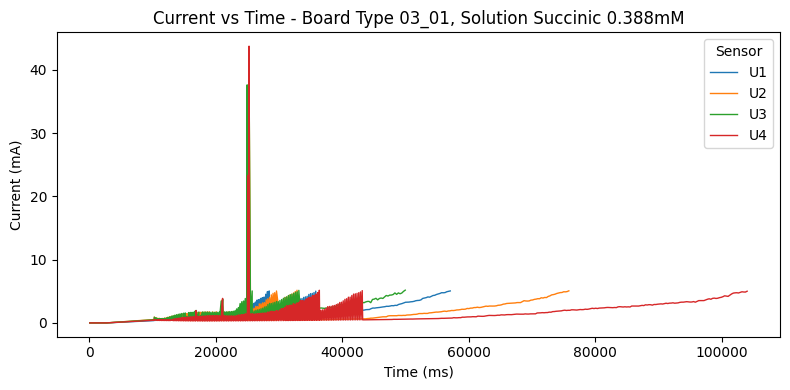

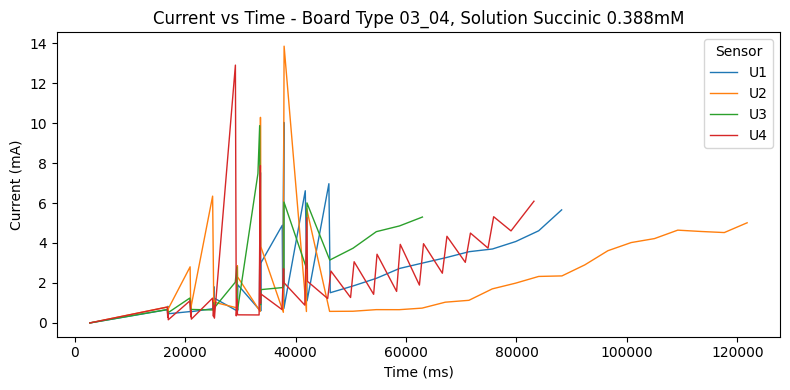

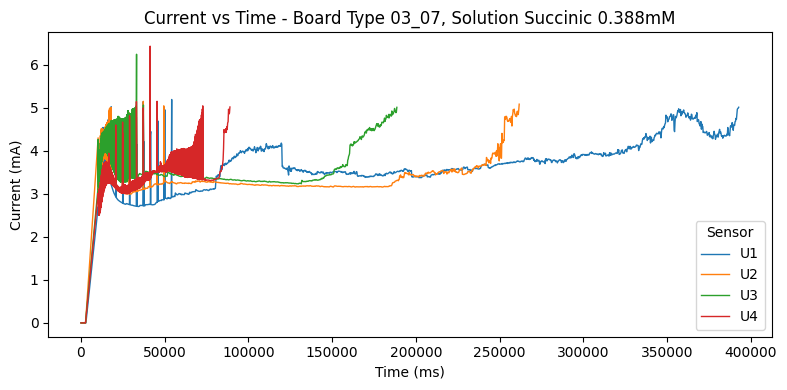

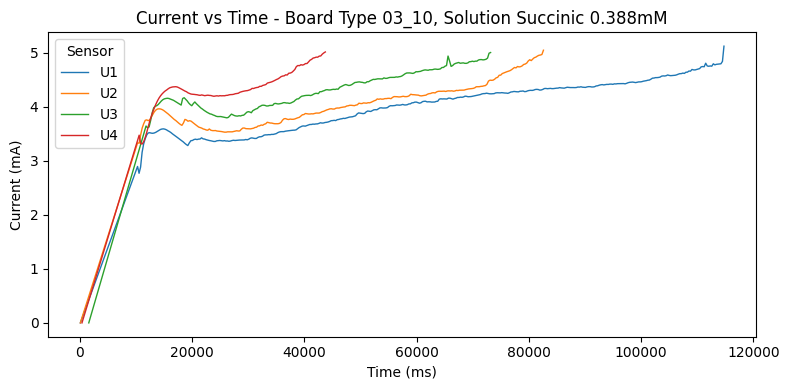

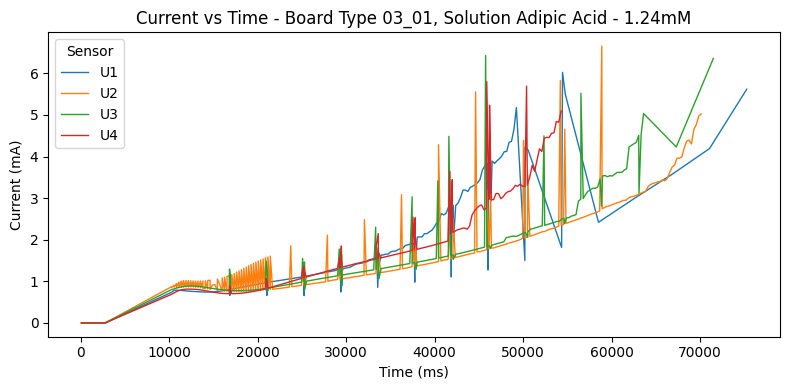

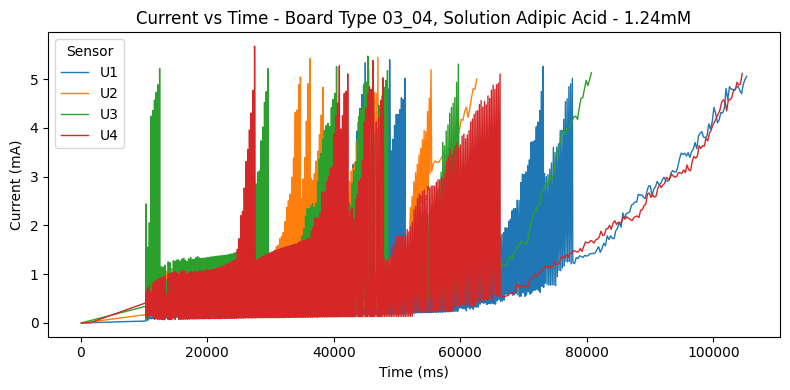

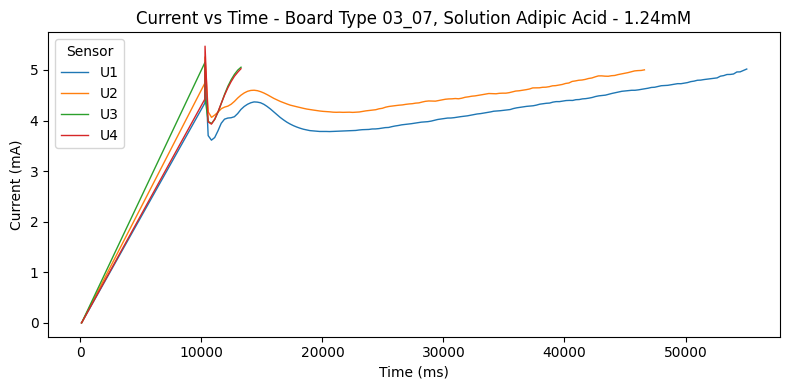

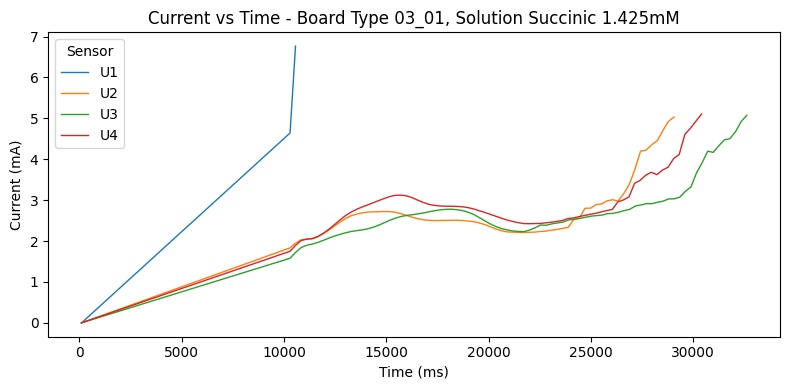

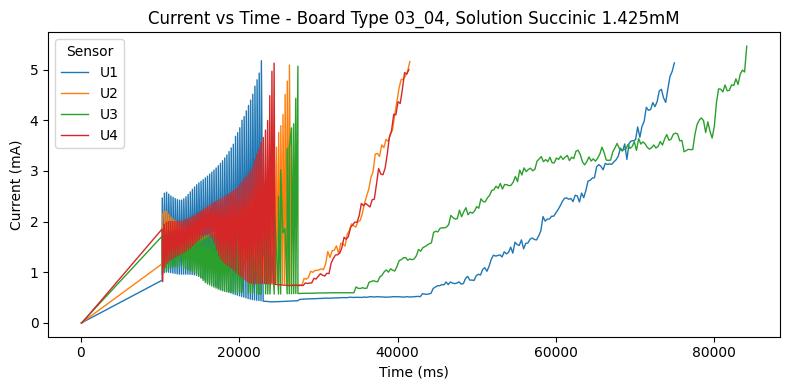

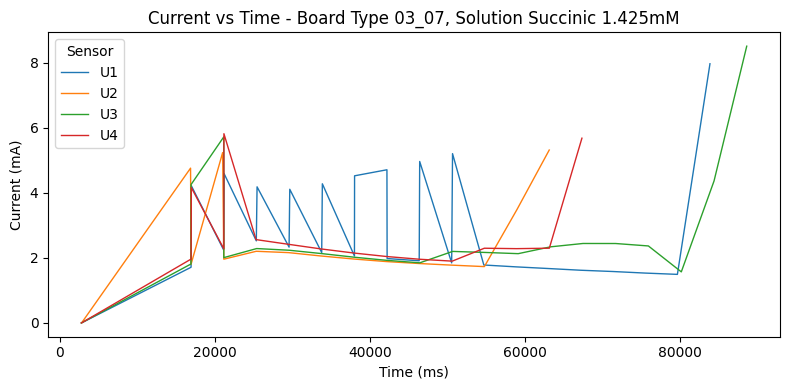

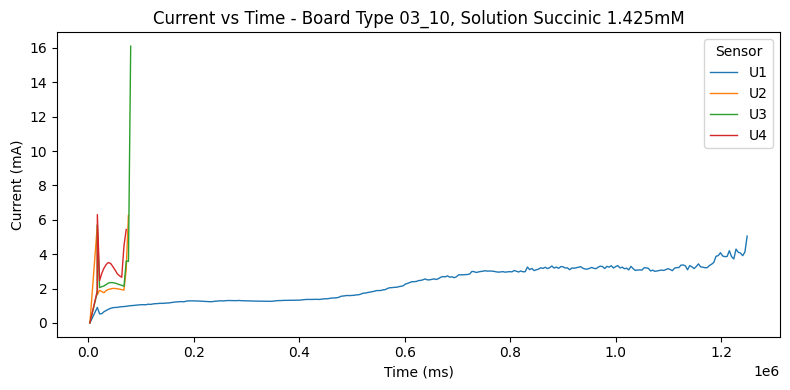

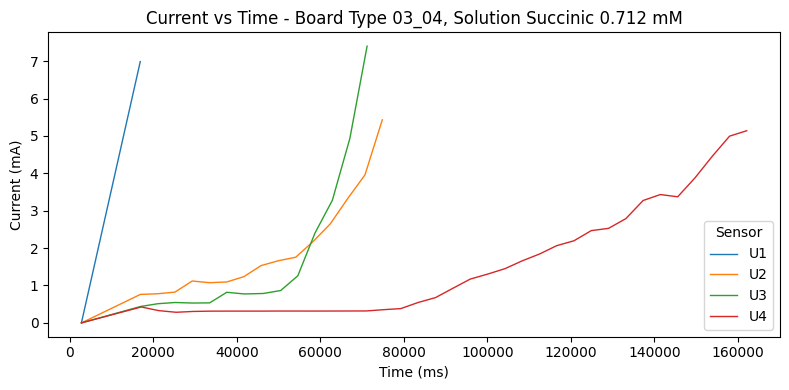

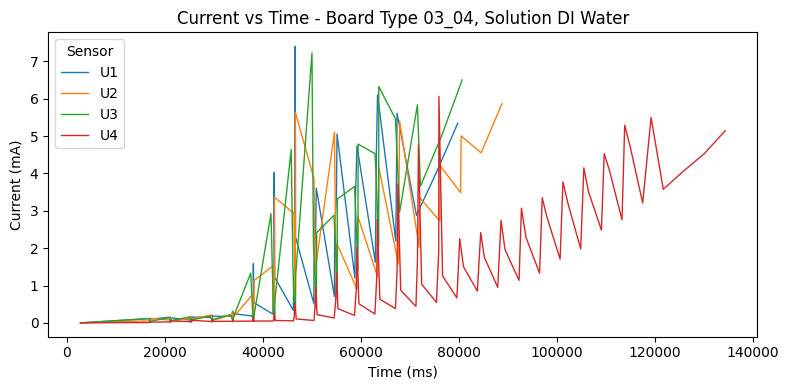

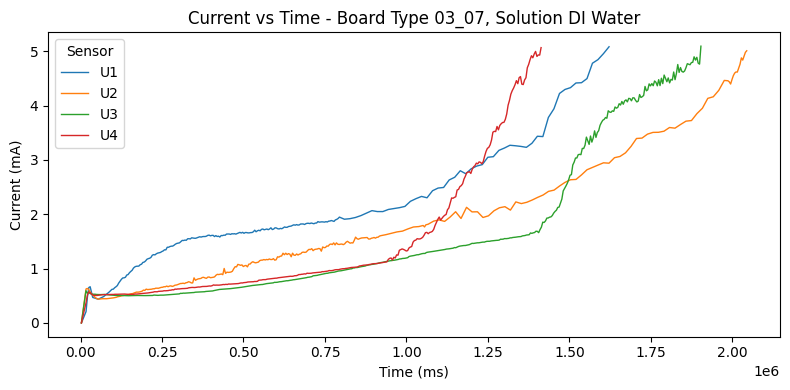

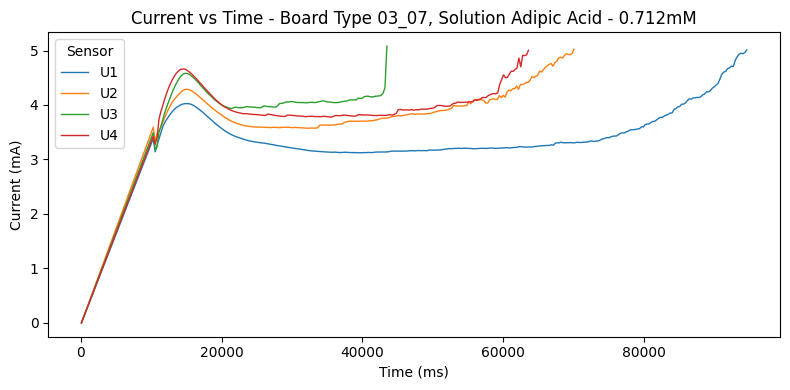

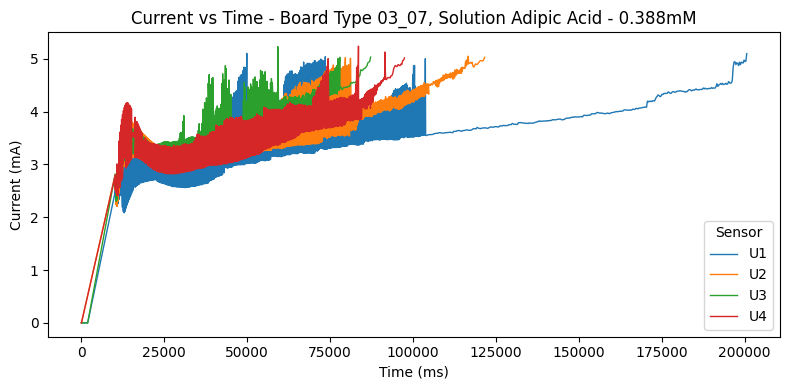

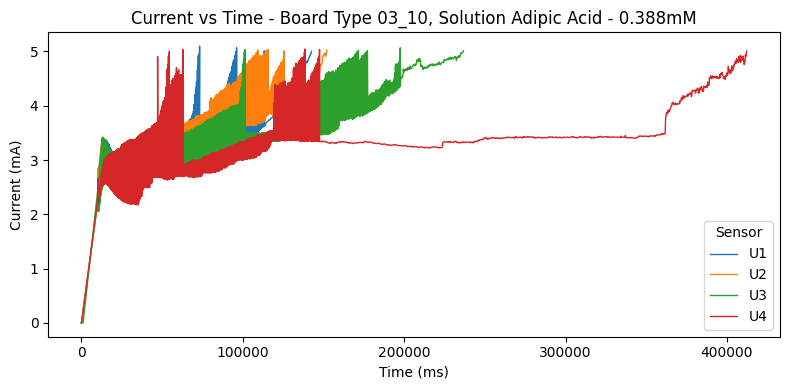

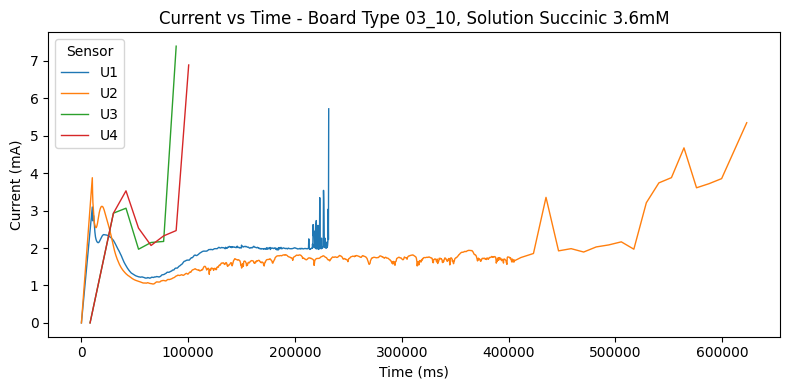

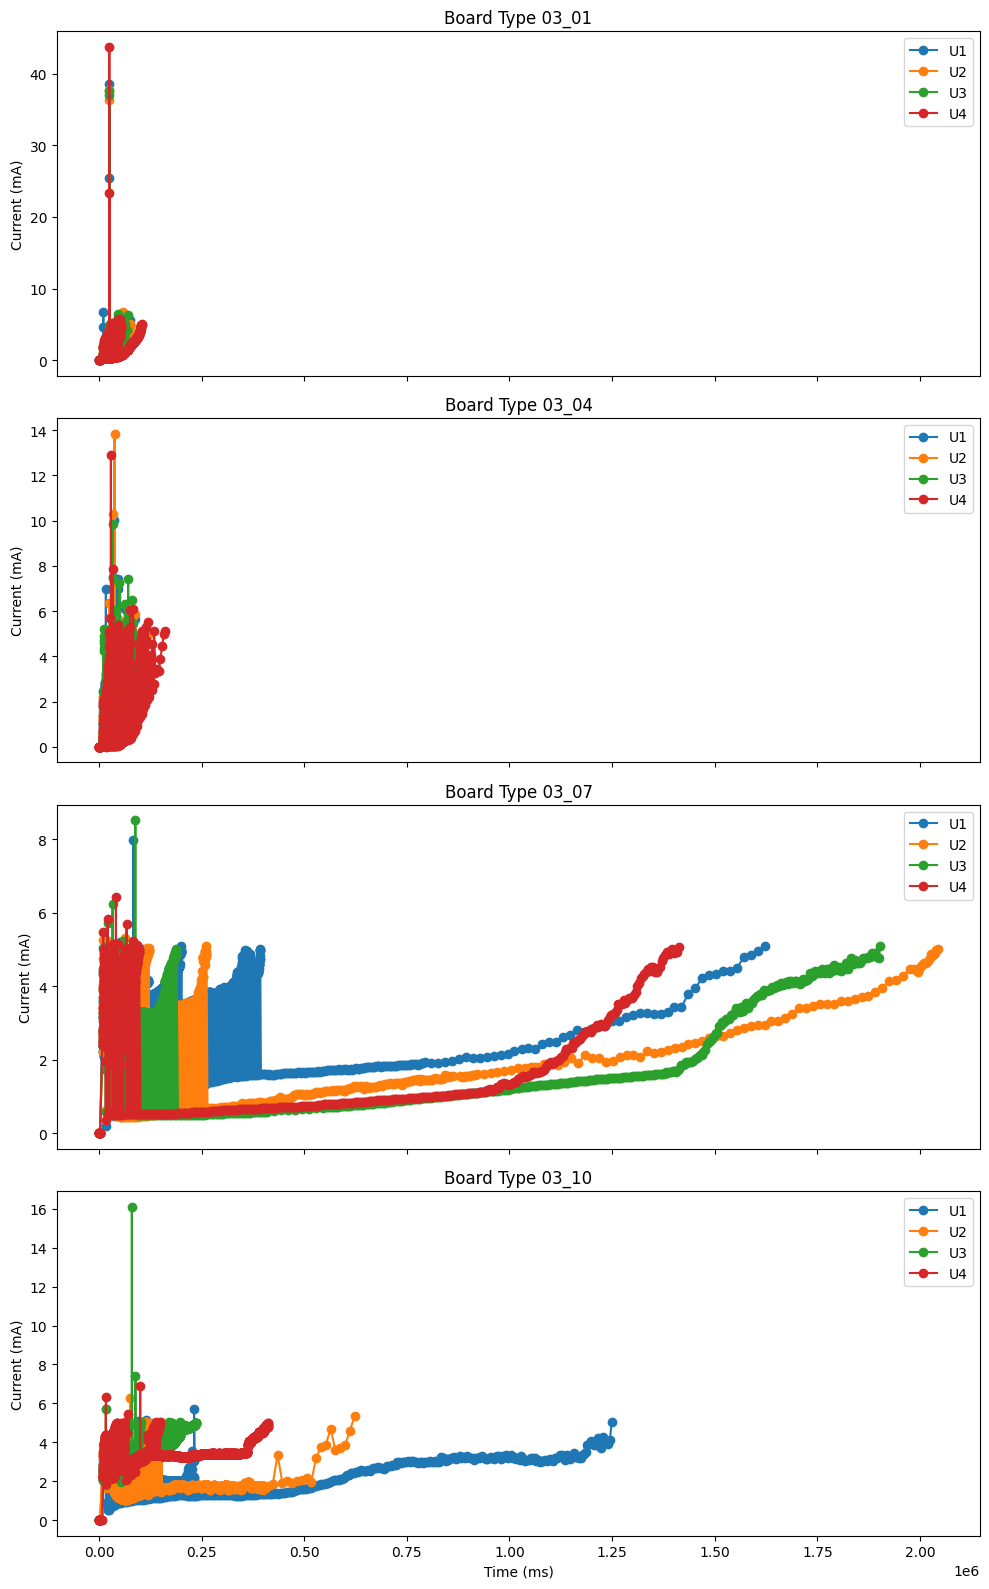

In [8]:
# -----------------------------
# Current vs Time by Board Type (raw)
# -----------------------------

import sys
sys.path.append("C:/Users/goodn/OneDrive/Documents/GitHub/darts_idc_analysis/Analysis")

import matplotlib.pyplot as plt
%matplotlib inline

import adds
import pandas as pd

# Load data
master_current_time = adds.get_master_current_time()

# Extract Board Type (first 5 characters of Board ID)
master_current_time["Board Type"] = master_current_time["Board ID"].str[:5]

# Get unique solutions and board types
solutions = master_current_time["Solution"].unique()
board_types = master_current_time["Board Type"].unique()

# Plot loop
for sol in solutions:
    for btype in board_types:
        df = master_current_time[
            (master_current_time["Solution"] == sol) &
            (master_current_time["Board Type"] == btype)
        ]
        if df.empty:
            continue  # skip if no data

        # Average across boards of the same type for each sensor
        df_avg = df.groupby(["Sensor", "Time (ms)"])["Current (mA)"].mean().reset_index()

        plt.figure(figsize=(8, 4))

        # Plot raw lines for each sensor
        for sensor in df_avg["Sensor"].unique():
            sensor_df = df_avg[df_avg["Sensor"] == sensor]
            plt.plot(sensor_df["Time (ms)"], sensor_df["Current (mA)"], label=sensor, linewidth=1)

        plt.title(f"Current vs Time - Board Type {btype}, Solution {sol}")
        plt.xlabel("Time (ms)")
        plt.ylabel("Current (mA)")
        plt.legend(title="Sensor")
        plt.tight_layout()
        plt.show()



fig, axes = plt.subplots(nrows=len(board_types), ncols=1, figsize=(10, 4*len(board_types)), sharex=True)
for ax, btype in zip(axes, board_types):
    df = master_current_time[master_current_time["Board Type"] == btype]
    df_avg = df.groupby(["Sensor", "Time (ms)"])["Current (mA)"].mean().reset_index()
    for sensor in df_avg["Sensor"].unique():
        sensor_df = df_avg[df_avg["Sensor"] == sensor]
        ax.plot(sensor_df["Time (ms)"], sensor_df["Current (mA)"], marker="o", label=sensor)
    ax.set_title(f"Board Type {btype}")
    ax.set_ylabel("Current (mA)")
    ax.legend()

axes[-1].set_xlabel("Time (ms)")
plt.tight_layout()
plt.show()
